# Data Understanding & Deduplikasi Dataset ISIC (2016–2024) & HAM10000


## Langkah 1 — Setup Folder & Load Semua Dataset
Menyiapkan library, konfigurasi folder dataset, pemindaian file gambar fisik, dan pemuatan ground truth CSV.

In [32]:
from IPython.display import display
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from itertools import combinations
from PIL import Image
import warnings

warnings.filterwarnings('ignore')

# Setting visualisasi agar rapi
sns.set_theme(style='whitegrid')
plt.rcParams['font.sans-serif'] = 'Arial'

# Otomatis deteksi folder Dataset (fleksibel dari root workspace atau subfolder kode)
folder_aktif = os.getcwd()
if os.path.exists(os.path.join(folder_aktif, 'Dataset')):
    ROOT = os.path.join(folder_aktif, 'Dataset')
elif os.path.exists(os.path.join(os.path.dirname(folder_aktif), 'Dataset')):
    ROOT = os.path.join(os.path.dirname(folder_aktif), 'Dataset')
else:
    ROOT = r"C:\Users\ARII\Downloads\Data Understanding Isic & Ham10k\Dataset"

print("Folder dataset aktif:", ROOT)

# Konfigurasi 14 sumber dataset ISIC dan HAM10000
SOURCES = {
    'isic_2016_train': {
        'year': '2016', 'split': 'train', 'gt_format': '2016',
        'img_dir': os.path.join(ROOT, 'isic 2016', 'ISBI2016_ISIC_Part3_Training_Data', 'ISBI2016_ISIC_Part3_Training_Data'),
        'gt_path': os.path.join(ROOT, 'isic 2016', 'ISBI2016_ISIC_Part3_Training_Data', 'ISBI2016_ISIC_Part3_Training_GroundTruth.csv'),
    },
    'isic_2016_test': {
        'year': '2016', 'split': 'test', 'gt_format': '2016',
        'img_dir': os.path.join(ROOT, 'isic 2016', 'ISBI2016_ISIC_Part3_Test_Data', 'ISBI2016_ISIC_Part3_Test_Data'),
        'gt_path': os.path.join(ROOT, 'isic 2016', 'ISBI2016_ISIC_Part3_Test_Data', 'ISBI2016_ISIC_Part3_Test_GroundTruth.csv'),
    },
    'isic_2017_train': {
        'year': '2017', 'split': 'train', 'gt_format': '2017',
        'img_dir': os.path.join(ROOT, 'isic 2017', 'ISIC-2017_Training_Data', 'ISIC-2017_Training_Data'),
        'gt_path': os.path.join(ROOT, 'isic 2017', 'ISIC-2017_Training_Data', 'ISIC-2017_Training_Part3_GroundTruth.csv'),
        'meta_path': os.path.join(ROOT, 'isic 2017', 'ISIC-2017_Training_Data', 'ISIC-2017_Training_Data', 'ISIC-2017_Training_Data_metadata.csv'),
    },
    'isic_2017_val': {
        'year': '2017', 'split': 'val', 'gt_format': '2017',
        'img_dir': os.path.join(ROOT, 'isic 2017', 'ISIC-2017_Validation_Data', 'ISIC-2017_Validation_Data'),
        'gt_path': os.path.join(ROOT, 'isic 2017', 'ISIC-2017_Validation_Data', 'ISIC-2017_Validation_Part3_GroundTruth.csv'),
        'meta_path': os.path.join(ROOT, 'isic 2017', 'ISIC-2017_Validation_Data', 'ISIC-2017_Validation_Data', 'ISIC-2017_Validation_Data_metadata.csv'),
    },
    'isic_2017_test': {
        'year': '2017', 'split': 'test', 'gt_format': '2017',
        'img_dir': os.path.join(ROOT, 'isic 2017', 'ISIC-2017_Test_v2_Data', 'ISIC-2017_Test_v2_Data'),
        'gt_path': os.path.join(ROOT, 'isic 2017', 'ISIC-2017_Test_v2_Data', 'ISIC-2017_Test_v2_Part3_GroundTruth.csv'),
        'meta_path': os.path.join(ROOT, 'isic 2017', 'ISIC-2017_Test_v2_Data', 'ISIC-2017_Test_v2_Data', 'ISIC-2017_Test_v2_Data_metadata.csv'),
    },
    'isic_2018_train': {
        'year': '2018', 'split': 'train', 'gt_format': 'onehot7',
        'img_dir': os.path.join(ROOT, 'isic 2018', 'ISIC2018_Task3_Training_Input', 'ISIC2018_Task3_Training_Input'),
        'gt_path': os.path.join(ROOT, 'isic 2018', 'ISIC2018_Task3_Training_Input', 'ISIC2018_Task3_Training_GroundTruth', 'ISIC2018_Task3_Training_GroundTruth', 'ISIC2018_Task3_Training_GroundTruth.csv'),
        'meta_path': os.path.join(ROOT, 'isic 2018', 'ISIC2018_Task3_Training_LesionGroupings.csv'),
    },
    'isic_2018_val': {
        'year': '2018', 'split': 'val', 'gt_format': 'onehot7',
        'img_dir': os.path.join(ROOT, 'isic 2018', 'ISIC2018_Task3_Validation_Input'),
        'gt_path': os.path.join(ROOT, 'isic 2018', 'ISIC2018_Task3_Validation_Input', 'ISIC2018_Task3_Validation_GroundTruth', 'ISIC2018_Task3_Validation_GroundTruth', 'ISIC2018_Task3_Validation_GroundTruth.csv'),
    },
    'isic_2018_test': {
        'year': '2018', 'split': 'test', 'gt_format': 'onehot7',
        'img_dir': os.path.join(ROOT, 'isic 2018', 'ISIC2018_Task3_Test_Input', 'ISIC2018_Task3_Test_Input'),
        'gt_path': os.path.join(ROOT, 'isic 2018', 'ISIC2018_Task3_Test_Input', 'ISIC2018_Task3_Test_GroundTruth', 'ISIC2018_Task3_Test_GroundTruth', 'ISIC2018_Task3_Test_GroundTruth.csv'),
    },
    'isic_2019_train': {
        'year': '2019', 'split': 'train', 'gt_format': 'onehot9',
        'img_dir': os.path.join(ROOT, 'isic 2019', 'ISIC_2019_Training_Input', 'ISIC_2019_Training_Input'),
        'gt_path': os.path.join(ROOT, 'isic 2019', 'ISIC_2019_Training_Input', 'ISIC_2019_Training_GroundTruth.csv'),
        'meta_path': os.path.join(ROOT, 'isic 2019', 'ISIC_2019_Training_Input', 'ISIC_2019_Training_Metadata.csv'),
    },
    'isic_2019_test': {
        'year': '2019', 'split': 'test', 'gt_format': 'onehot9',
        'img_dir': os.path.join(ROOT, 'isic 2019', 'ISIC_2019_Test_Input', 'ISIC_2019_Test_Input'),
        'gt_path': os.path.join(ROOT, 'isic 2019', 'ISIC_2019_Test_Input', 'ISIC_2019_Test_GroundTruth.csv'),
        'meta_path': os.path.join(ROOT, 'isic 2019', 'ISIC_2019_Test_Input', 'ISIC_2019_Test_Metadata.csv'),
    },
    'isic_2020_train': {
        'year': '2020', 'split': 'train', 'gt_format': '2020',
        'img_dir': os.path.join(ROOT, 'isic 2020', 'ISIC_2020_Training_JPEG', 'train'),
        'gt_path': os.path.join(ROOT, 'isic 2020', 'ISIC_2020_Training_JPEG', 'ISIC_2020_Training_GroundTruth_v2.csv'),
        'dup_path': os.path.join(ROOT, 'isic 2020', 'ISIC_2020_Training_JPEG', 'ISIC_2020_Training_Duplicates.csv'),
    },
    'isic_2020_test': {
        'year': '2020', 'split': 'test', 'gt_format': None,
        'img_dir': os.path.join(ROOT, 'isic 2020', 'ISIC_2020_Test_JPEG', 'ISIC_2020_Test_Input'),
        'gt_path': None,
        'meta_path': os.path.join(ROOT, 'isic 2020', 'ISIC_2020_Test_JPEG', 'ISIC_2020_Test_Metadata.csv'),
    },
    'isic_2024_train': {
        'year': '2024', 'split': 'train', 'gt_format': '2024',
        'img_dir': os.path.join(ROOT, 'isic 2024', 'ISIC_2024_Training_Input', 'ISIC_2024_Training_Input'),
        'gt_path': os.path.join(ROOT, 'isic 2024', 'ISIC_2024_Training_Input', 'ISIC_2024_Training_GroundTruth.csv'),
        'meta_path': os.path.join(ROOT, 'isic 2024', 'ISIC_2024_Training_Input', 'ISIC_2024_Training_Input', 'metadata.csv'),
        'supp_path': os.path.join(ROOT, 'isic 2024', 'ISIC_2024_Training_Input', 'ISIC_2024_Training_Supplement.csv'),
    },
    'ham10000': {
        'year': '2018', 'split': 'train', 'gt_format': 'ham_dx',
        'img_dirs': [
            os.path.join(ROOT, 'HAM10K', 'HAM10000_images_part_1'),
            os.path.join(ROOT, 'HAM10K', 'HAM10000_images_part_2'),
        ],
        'gt_path': os.path.join(ROOT, 'HAM10K', 'HAM10000_metadata'),
    },
}

print(f"Total dataset terdaftar: {len(SOURCES)} sumber.")

Folder dataset aktif: c:\Users\ARII\Downloads\Data Understanding Isic & Ham10k\Dataset
Total dataset terdaftar: 14 sumber.


In [33]:
# Scan file gambar fisik (.jpg/.jpeg) dan muat CSV ground truth ke memory
IMG_EXT = ('.jpg', '.jpeg')
all_images = []

for source, info in SOURCES.items():
    if 'img_dirs' in info:
        for d in info['img_dirs']:
            if os.path.exists(d):
                for f in os.listdir(d):
                    if f.lower().endswith(IMG_EXT):
                        all_images.append({'image_id': os.path.splitext(f)[0], 'source': source, 'filepath': os.path.join(d, f)})
    else:
        d = info.get('img_dir')
        if d and os.path.exists(d):
            for root_dir, _, files in os.walk(d):
                if '__MACOSX' in root_dir:
                    continue
                for f in files:
                    if f.lower().endswith(IMG_EXT) and not f.startswith('._'):
                        all_images.append({'image_id': os.path.splitext(f)[0], 'source': source, 'filepath': os.path.join(root_dir, f)})

df_images = pd.DataFrame(all_images)

# Baca semua CSV ground truth
ground_truth_dfs = {}
for source, info in SOURCES.items():
    p = info.get('gt_path')
    fmt = info.get('gt_format')
    if p and os.path.exists(p):
        if fmt == '2016':
            df_gt = pd.read_csv(p, header=None, names=['image_id', 'label'])
        else:
            df_gt = pd.read_csv(p)
            id_col = next((c for c in ['image_id', 'image', 'image_name', 'isic_id'] if c in df_gt.columns), df_gt.columns[0])
            if id_col != 'image_id':
                df_gt.rename(columns={id_col: 'image_id'}, inplace=True)
                
        df_gt['image_id'] = df_gt['image_id'].astype(str).str.replace('.jpg', '', regex=False)
        ground_truth_dfs[source] = df_gt

print(f"Total gambar fisik terindeks: {len(df_images):,} gambar.")

Total gambar fisik terindeks: 504,500 gambar.


## Langkah 2 — Validasi Kelengkapan (File Gambar vs CSV)
Mencocokkan jumlah gambar di folder dengan rekaman CSV untuk memastikan tidak ada data yang hilang atau nyasar.

In [34]:
val_rows = []
for source, info in SOURCES.items():
    n_file = len(df_images[df_images['source'] == source])
    gt = ground_truth_dfs.get(source)
    n_csv = len(gt) if gt is not None else None
    
    if gt is not None:
        set_file = set(df_images[df_images['source'] == source]['image_id'])
        set_csv = set(gt['image_id'])
        orphan = len(set_file - set_csv)
        missing = len(set_csv - set_file)
        status = 'OK (Cocok)' if orphan == 0 and missing == 0 else 'Ada Selisih'
    else:
        # Pengecekan ISIC 2020 Test via metadata
        meta_p = info.get('meta_path')
        if meta_p and os.path.exists(meta_p):
            df_meta = pd.read_csv(meta_p)
            id_col = 'image' if 'image' in df_meta.columns else df_meta.columns[0]
            set_file = set(df_images[df_images['source'] == source]['image_id'])
            set_csv = set(df_meta[id_col].astype(str).str.replace('.jpg', '', regex=False))
            orphan = len(set_file - set_csv)
            missing = len(set_csv - set_file)
            n_csv = len(df_meta)
            status = 'OK (Cocok via Metadata)' if orphan == 0 and missing == 0 else 'Ada Selisih'
        else:
            orphan, missing, status = '-', '-', 'Test Unlabeled'
        
    val_rows.append({
        'Source Dataset': source,
        'File Fisik di Folder': f"{n_file:,}",
        'Baris di CSV': f"{n_csv:,}" if isinstance(n_csv, int) else (n_csv or 'N/A'),
        'File Nyasar (Orphan)': orphan,
        'File Hilang (Missing)': missing,
        'Status': status
    })

df_validation = pd.DataFrame(val_rows)
display(df_validation)

,Source Dataset,File Fisik di Folder,Baris di CSV,File Nyasar (Orphan),File Hilang (Missing),Status
0,isic_2016_train,900,900,0,0,OK (Cocok)
1,isic_2016_test,379,379,0,0,OK (Cocok)
2,isic_2017_train,"2,000","2,000",0,0,OK (Cocok)
3,isic_2017_val,150,150,0,0,OK (Cocok)
4,isic_2017_test,600,600,0,0,OK (Cocok)
5,isic_2018_train,"10,015","10,015",0,0,OK (Cocok)
6,isic_2018_val,193,193,0,0,OK (Cocok)
7,isic_2018_test,"1,512","1,512",0,0,OK (Cocok)
8,isic_2019_train,"25,331","25,331",0,0,OK (Cocok)
9,isic_2019_test,"8,238","8,238",0,0,OK (Cocok)


## Langkah 3 — Analisis Distribusi Diagnosis Asli Tiap Dataset
Melihat daftar diagnosis asli bawaan tiap dataset beserta jumlah dan persentasenya (tanpa pengelompokan biner prematur).

In [35]:
# Kamus keterangan nama medis lengkap untuk label asli
CLASS_INFO = {
    'nv': 'Melanocytic Nevus (Tahi Lalat Biasa)',
    'NV': 'Melanocytic Nevus (Tahi Lalat Biasa)',
    'nevus': 'Melanocytic Nevus (Tahi Lalat Biasa)',
    'mel': 'Melanoma Maligna (Kanker Melanositik)',
    'MEL': 'Melanoma Maligna (Kanker Melanositik)',
    'melanoma': 'Melanoma Maligna (Kanker Melanositik)',
    'bcc': 'Basal Cell Carcinoma (Karsinoma Sel Basal)',
    'BCC': 'Basal Cell Carcinoma (Karsinoma Sel Basal)',
    'akiec': 'Actinic Keratosis / Bowen Disease (Pra-Kanker)',
    'AKIEC': 'Actinic Keratosis / Bowen Disease (Pra-Kanker)',
    'ak': 'Actinic Keratosis (Pra-Kanker)',
    'AK': 'Actinic Keratosis (Pra-Kanker)',
    'scc': 'Squamous Cell Carcinoma (Karsinoma Sel Skuamosa)',
    'SCC': 'Squamous Cell Carcinoma (Karsinoma Sel Skuamosa)',
    'bkl': 'Benign Keratosis (Keratosis Seboroik / Lentigo)',
    'BKL': 'Benign Keratosis (Keratosis Seboroik / Lentigo)',
    'seborrheic_keratosis': 'Seborrheic Keratosis',
    'df': 'Dermatofibroma (Nodul Kulit Jinak)',
    'DF': 'Dermatofibroma (Nodul Kulit Jinak)',
    'vasc': 'Vascular Lesion (Kelainan Pembuluh Darah)',
    'VASC': 'Vascular Lesion (Kelainan Pembuluh Darah)',
    'benign': 'Benign (Lesi Jinak Bawaan)',
    'benign (0)': 'Benign / Target 0 (Lesi Jinak Bawaan)',
    'malignant': 'Malignant (Kanker Kulit Ganas Bawaan)',
    'malignant (1)': 'Malignant / Target 1 (Kanker Kulit Ganas Bawaan)',
    'UNK': 'Unknown / Out of Distribution',
    'unlabeled (test)': 'Unlabeled Test Set (Data Uji Kompetisi)'
}

detailed_class_list = []
summary_dataset_rows = []

for source, info in SOURCES.items():
    fmt = info.get('gt_format')
    p = info.get('gt_path')
    if not p or not os.path.exists(p):
        n_file = len(df_images[df_images['source'] == source])
        detailed_class_list.append({
            'Source Dataset': source,
            'Nama Kelas Asli': 'unlabeled (test)',
            'Keterangan Medis': CLASS_INFO.get('unlabeled (test)'),
            'Jumlah Gambar': n_file,
            'Persentase': '100.0%',
            'raw_count': n_file
        })
        summary_dataset_rows.append({
            'Source Dataset': source,
            'Total Data': f"{n_file:,}",
            'Format Diagnosis': 'Unlabeled (Metadata)',
            'Jumlah Kelas': 0,
            'Daftar Kelas Asli': 'unlabeled (test)'
        })
        continue
        
    gt = ground_truth_dfs.get(source)
    total_samples = len(gt)
    classes_in_source = []
    
    if fmt == '2016':
        counts = gt['label'].astype(str).str.lower().value_counts()
        for cls_name, cnt in counts.items():
            name_clean = 'malignant' if cls_name in ['malignant', '1.0', '1'] else 'benign'
            classes_in_source.append(name_clean)
            detailed_class_list.append({
                'Source Dataset': source,
                'Nama Kelas Asli': name_clean,
                'Keterangan Medis': CLASS_INFO.get(name_clean, name_clean),
                'Jumlah Gambar': int(cnt),
                'Persentase': f"{cnt / total_samples * 100:.2f}%",
                'raw_count': int(cnt)
            })
    elif fmt == '2017':
        n_mel = int((gt['melanoma'] == 1.0).sum())
        n_sk = int((gt['seborrheic_keratosis'] == 1.0).sum())
        n_nev = total_samples - n_mel - n_sk
        for cls_name, cnt in [('nevus', n_nev), ('melanoma', n_mel), ('seborrheic_keratosis', n_sk)]:
            classes_in_source.append(cls_name)
            detailed_class_list.append({
                'Source Dataset': source,
                'Nama Kelas Asli': cls_name,
                'Keterangan Medis': CLASS_INFO.get(cls_name, cls_name),
                'Jumlah Gambar': cnt,
                'Persentase': f"{cnt / total_samples * 100:.2f}%",
                'raw_count': cnt
            })
    elif fmt in ('onehot7', 'onehot9'):
        cols = [c for c in gt.columns if c not in ('image_id', 'image', 'image_name', 'isic_id', 'score_weight', 'validation_weight')]
        classes_in_source = cols
        counts_dict = {c: int((gt[c] == 1.0).sum()) for c in cols}
        for c, cnt in sorted(counts_dict.items(), key=lambda x: x[1], reverse=True):
            detailed_class_list.append({
                'Source Dataset': source,
                'Nama Kelas Asli': c,
                'Keterangan Medis': CLASS_INFO.get(c, c),
                'Jumlah Gambar': cnt,
                'Persentase': f"{cnt / total_samples * 100:.2f}%",
                'raw_count': cnt
            })
    elif fmt in ('2020', '2024'):
        tgt_col = 'target' if fmt == '2020' else 'malignant'
        n_mal = int((gt[tgt_col] == 1).sum())
        n_ben = total_samples - n_mal
        classes_in_source = ['benign (0)', 'malignant (1)']
        for cls_name, cnt in [('benign (0)', n_ben), ('malignant (1)', n_mal)]:
            detailed_class_list.append({
                'Source Dataset': source,
                'Nama Kelas Asli': cls_name,
                'Keterangan Medis': CLASS_INFO.get(cls_name, cls_name),
                'Jumlah Gambar': cnt,
                'Persentase': f"{cnt / total_samples * 100:.2f}%",
                'raw_count': cnt
            })
    elif fmt == 'ham_dx':
        counts = gt['dx'].value_counts()
        classes_in_source = sorted(gt['dx'].unique().tolist())
        for cls_name, cnt in counts.items():
            detailed_class_list.append({
                'Source Dataset': source,
                'Nama Kelas Asli': cls_name,
                'Keterangan Medis': CLASS_INFO.get(cls_name, cls_name),
                'Jumlah Gambar': int(cnt),
                'Persentase': f"{cnt / total_samples * 100:.2f}%",
                'raw_count': int(cnt)
            })

    summary_dataset_rows.append({
        'Source Dataset': source,
        'Total Data': f"{total_samples:,}",
        'Format Diagnosis': fmt,
        'Jumlah Kelas': len(classes_in_source),
        'Daftar Kelas Asli': ', '.join(classes_in_source)
    })

df_class_detail = pd.DataFrame(detailed_class_list)
df_dataset_summary = pd.DataFrame(summary_dataset_rows)

In [36]:
# 1. Tabel Ringkasan Diagnosis per Dataset (14 Sumber)
print("=== RINGKASAN FORMAT & JUMLAH KELAS ASLI PER DATASET ===")
display(df_dataset_summary)

=== RINGKASAN FORMAT & JUMLAH KELAS ASLI PER DATASET ===


,Source Dataset,Total Data,Format Diagnosis,Jumlah Kelas,Daftar Kelas Asli
0,isic_2016_train,900,2016,2,"benign, malignant"
1,isic_2016_test,379,2016,2,"benign, malignant"
2,isic_2017_train,"2,000",2017,3,"nevus, melanoma, seborrheic_keratosis"
3,isic_2017_val,150,2017,3,"nevus, melanoma, seborrheic_keratosis"
4,isic_2017_test,600,2017,3,"nevus, melanoma, seborrheic_keratosis"
5,isic_2018_train,"10,015",onehot7,7,"MEL, NV, BCC, AKIEC, BKL, DF, VASC"
6,isic_2018_val,193,onehot7,7,"MEL, NV, BCC, AKIEC, BKL, DF, VASC"
7,isic_2018_test,"1,512",onehot7,7,"MEL, NV, BCC, AKIEC, BKL, DF, VASC"
8,isic_2019_train,"25,331",onehot9,9,"MEL, NV, BCC, AK, BKL, DF, VASC, SCC, UNK"
9,isic_2019_test,"8,238",onehot9,9,"MEL, NV, BCC, AK, BKL, DF, VASC, SCC, UNK"


In [37]:
# 2. Tabel Lengkap Seluruh Kelas Asli (SEMUA baris tanpa terpotong)
pd.set_option('display.max_rows', 100)
df_tampil = df_class_detail[['Source Dataset', 'Nama Kelas Asli', 'Keterangan Medis', 'Jumlah Gambar', 'Persentase']].copy()
df_tampil['Jumlah Gambar'] = df_tampil['Jumlah Gambar'].apply(lambda x: f"{x:,}" if isinstance(x, int) else x)

print("=== RINCIAN LENGKAP JUMLAH & PERSENTASE SELURUH KELAS ASLI (SEMUA DATASET) ===")
display(df_tampil)

=== RINCIAN LENGKAP JUMLAH & PERSENTASE SELURUH KELAS ASLI (SEMUA DATASET) ===


,Source Dataset,Nama Kelas Asli,Keterangan Medis,Jumlah Gambar,Persentase
0,isic_2016_train,benign,Benign (Lesi Jinak Bawaan),727,80.78%
1,isic_2016_train,malignant,Malignant (Kanker Kulit Ganas Bawaan),173,19.22%
2,isic_2016_test,benign,Benign (Lesi Jinak Bawaan),304,80.21%
3,isic_2016_test,malignant,Malignant (Kanker Kulit Ganas Bawaan),75,19.79%
4,isic_2017_train,nevus,Melanocytic Nevus (Tahi Lalat Biasa),"1,372",68.60%
5,isic_2017_train,melanoma,Melanoma Maligna (Kanker Melanositik),374,18.70%
6,isic_2017_train,seborrheic_keratosis,Seborrheic Keratosis,254,12.70%
7,isic_2017_val,nevus,Melanocytic Nevus (Tahi Lalat Biasa),78,52.00%
8,isic_2017_val,melanoma,Melanoma Maligna (Kanker Melanositik),30,20.00%
9,isic_2017_val,seborrheic_keratosis,Seborrheic Keratosis,42,28.00%


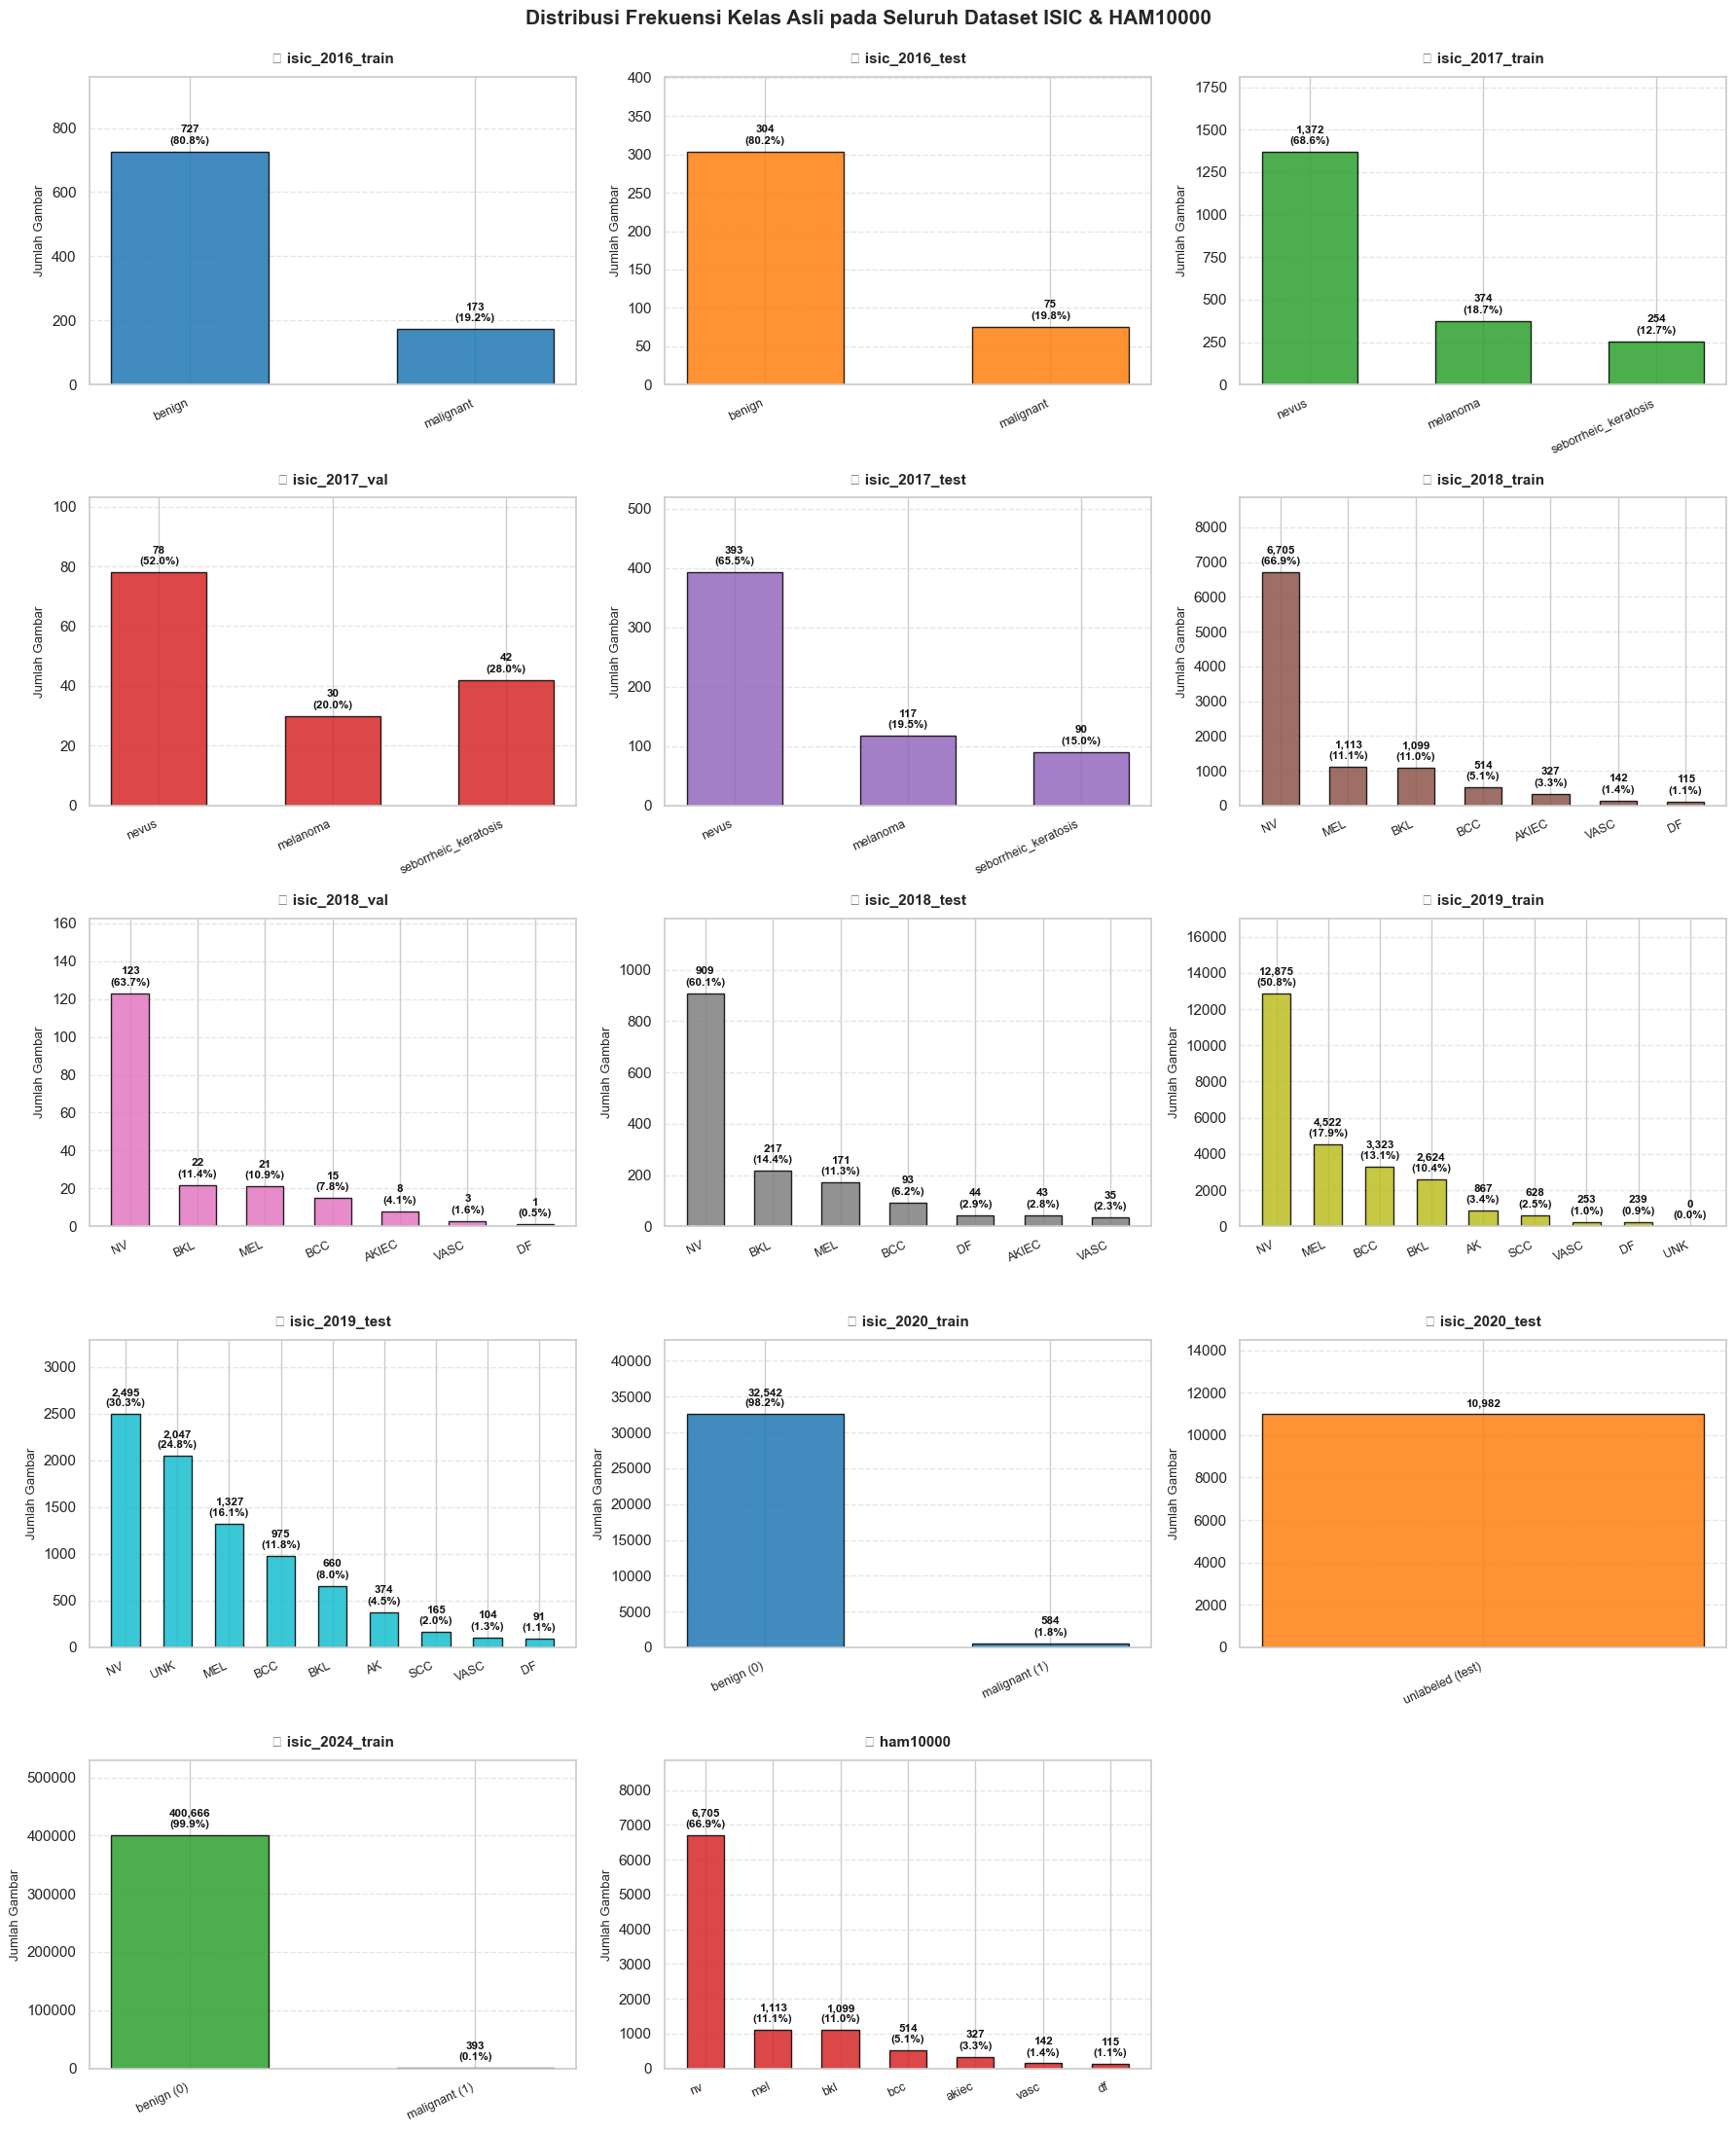

In [38]:
# 3. Visualisasi Grafik Bar Chart Distribusi Kelas Asli (Dengan Angka & Persentase Jelas)
sources_to_plot = list(SOURCES.keys())
fig, axes = plt.subplots(5, 3, figsize=(18, 22))
axes_flat = axes.flatten()
colors = sns.color_palette('tab10', 10)

for idx, src in enumerate(sources_to_plot):
    ax = axes_flat[idx]
    df_sub = df_class_detail[df_class_detail['Source Dataset'] == src]
    
    x_labels = df_sub['Nama Kelas Asli'].tolist()
    y_values = df_sub['raw_count'].tolist()
    total_in_src = sum(y_values)
    
    bars = ax.bar(x_labels, y_values, color=colors[idx % len(colors)], edgecolor='black', alpha=0.85, width=0.55)
    ax.set_title(f"📊 {src}", fontsize=11, fontweight='bold', pad=10)
    ax.set_ylabel("Jumlah Gambar", fontsize=9.5)
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    
    # Beri ruang atas agar angka tidak kepotong batas grafik
    max_y = max(y_values) if y_values else 10
    ax.set_ylim(0, max_y * 1.32)
    
    # Tulis angka jumlah citra dan persentase tepat di atas setiap batang
    for bar in bars:
        h = bar.get_height()
        pct = (h / total_in_src * 100) if total_in_src > 0 else 0
        txt = f"{int(h):,}\n({pct:.1f}%)" if pct < 100 else f"{int(h):,}"
        ax.text(
            bar.get_x() + bar.get_width() / 2.0, 
            h + (max_y * 0.025), 
            txt, 
            ha='center', 
            va='bottom', 
            fontsize=8.5, 
            fontweight='bold', 
            color='#111111'
        )
                
    ax.set_xticks(range(len(x_labels)))
    ax.set_xticklabels(x_labels, rotation=25, ha='right', fontsize=9)

# Bersihkan slot grafik kosong
for j in range(len(sources_to_plot), len(axes_flat)):
    fig.delaxes(axes_flat[j])

plt.suptitle("Distribusi Frekuensi Kelas Asli pada Seluruh Dataset ISIC & HAM10000", fontsize=15, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

### Catatan Singkat Sebaran Kelas Asli
* **Tahi Lalat (Nevus / NV):** Selalu mendominasi lebih dari separuh data pada dataset multiclass (50%–67%).
* **Penyakit Langka:** Kategori seperti Dermatofibroma (`DF`) dan Vascular (`VASC`) jumlahnya sangat sedikit (<2%).
* **Ketimpangan ISIC 2024:** Dari 401.059 citra skrining, kasus kanker hanya berjumlah 393 citra (0.1%).

## Langkah 4 — Tabel Karakteristik Antar Dataset
Rangkuman tahun rilis, split data, jumlah citra, format label, dan metadata yang tersedia.

In [39]:
compare_rows = []

for source, info in SOURCES.items():
    year = info.get('year', '-')
    split = info.get('split', '-').capitalize()
    fmt = info.get('gt_format')
    n_images = len(df_images[df_images['source'] == source])
    gt = ground_truth_dfs.get(source)
    
    if gt is not None:
        if fmt == '2016':
            n_classes = '2 (Biner Teks)'
            target_desc = 'benign / malignant'
        elif fmt == '2017':
            n_classes = '3 (Multi-kolom)'
            target_desc = 'melanoma, seborrheic_keratosis, nevus'
        elif fmt == 'onehot7':
            cols = [c for c in gt.columns if c not in ('image_id', 'score_weight', 'validation_weight')]
            n_classes = f"{len(cols)} (One-hot)"
            target_desc = ', '.join(cols)
        elif fmt == 'onehot9':
            cols = [c for c in gt.columns if c not in ('image_id', 'score_weight', 'validation_weight')]
            n_classes = f"{len(cols)} (One-hot)"
            target_desc = ', '.join(cols)
        elif fmt in ('2020', '2024'):
            n_classes = '2 (Biner Target)'
            target_desc = 'target (0 / 1)'
        elif fmt == 'ham_dx':
            n_classes = f"{gt['dx'].nunique()} (String dx)"
            target_desc = ', '.join(sorted(gt['dx'].unique()))
    else:
        n_classes = 'Unlabeled'
        target_desc = 'Data Uji Kompetisi (Tanpa Label)'

    meta_cols = []
    for mp_key in ['meta_path', 'supp_path']:
        mp = info.get(mp_key)
        if mp and os.path.exists(mp):
            mdf = pd.read_csv(mp, nrows=2)
            meta_cols.extend([c for c in mdf.columns if c not in ['image_id', 'image', 'isic_id', 'image_name']])
            
    if gt is not None:
        extra = [c for c in gt.columns if c in ['patient_id', 'lesion_id', 'sex', 'age', 'age_approx', 'anatom_site_general_challenge', 'diagnosis', 'dx_type', 'localization']]
        meta_cols.extend(extra)
        
    meta_cols = sorted(list(set(meta_cols)))
    meta_desc = ', '.join(meta_cols[:5]) + ('...' if len(meta_cols) > 5 else '') if meta_cols else 'Tidak Ada'

    compare_rows.append({
        'Source Dataset': source,
        'Tahun': year,
        'Split': split,
        'Jumlah Citra': f"{n_images:,}",
        'Format Diagnosis': n_classes,
        'Daftar Kelas Asli': target_desc,
        'Metadata Tersedia': meta_desc
    })

df_compare = pd.DataFrame(compare_rows)
display(df_compare)

,Source Dataset,Tahun,Split,Jumlah Citra,Format Diagnosis,Daftar Kelas Asli,Metadata Tersedia
0,isic_2016_train,2016,Train,900,2 (Biner Teks),benign / malignant,Tidak Ada
1,isic_2016_test,2016,Test,379,2 (Biner Teks),benign / malignant,Tidak Ada
2,isic_2017_train,2017,Train,"2,000",3 (Multi-kolom),"melanoma, seborrheic_keratosis, nevus","age_approximate, sex"
3,isic_2017_val,2017,Val,150,3 (Multi-kolom),"melanoma, seborrheic_keratosis, nevus","age_approximate, sex"
4,isic_2017_test,2017,Test,600,3 (Multi-kolom),"melanoma, seborrheic_keratosis, nevus","age_approximate, sex"
5,isic_2018_train,2018,Train,"10,015",7 (One-hot),"MEL, NV, BCC, AKIEC, BKL, DF, VASC","diagnosis_confirm_type, lesion_id"
6,isic_2018_val,2018,Val,193,7 (One-hot),"MEL, NV, BCC, AKIEC, BKL, DF, VASC",Tidak Ada
7,isic_2018_test,2018,Test,"1,512",7 (One-hot),"MEL, NV, BCC, AKIEC, BKL, DF, VASC",Tidak Ada
8,isic_2019_train,2019,Train,"25,331",9 (One-hot),"MEL, NV, BCC, AK, BKL, DF, VASC, SCC, UNK","age_approx, anatom_site_general, lesion_id, sex"
9,isic_2019_test,2019,Test,"8,238",9 (One-hot),"MEL, NV, BCC, AK, BKL, DF, VASC, SCC, UNK",Tidak Ada


## Langkah 5 — Deteksi Gambar Duplikat Antar Dataset
Mendeteksi gambar yang muncul di lebih dari satu dataset karena dirilis ulang oleh konsorsium ISIC.

In [40]:
# Kelompokkan data berdasarkan image_id untuk melihat gambar yang muncul di >1 dataset
dup_group = df_images.groupby('image_id')['source'].apply(lambda x: sorted(list(set(x)))).reset_index()
dup_group['jumlah_source'] = dup_group['source'].apply(len)
df_dups = dup_group[dup_group['jumlah_source'] > 1].sort_values('jumlah_source', ascending=False)

print(f"Total image_id unik yang muncul di lebih dari 1 dataset: {len(df_dups):,} gambar")
display(df_dups.head(8))

Total image_id unik yang muncul di lebih dari 1 dataset: 12,886 gambar


,image_id,source,jumlah_source
0,ISIC_0000000,"[isic_2016_train, isic_2017_train, isic_2019_t...",3
11346,ISIC_0030597,"[ham10000, isic_2018_train, isic_2019_train]",3
11338,ISIC_0030589,"[ham10000, isic_2018_train, isic_2019_train]",3
11339,ISIC_0030590,"[ham10000, isic_2018_train, isic_2019_train]",3
11340,ISIC_0030591,"[ham10000, isic_2018_train, isic_2019_train]",3
11341,ISIC_0030592,"[ham10000, isic_2018_train, isic_2019_train]",3
11342,ISIC_0030593,"[ham10000, isic_2018_train, isic_2019_train]",3
11343,ISIC_0030594,"[ham10000, isic_2018_train, isic_2019_train]",3


In [41]:
# Hitung irisan gambar antar pasangan dataset
pair_counter = Counter()
for src_list in df_dups['source']:
    for a, b in combinations(src_list, 2):
        pair_counter[(a, b)] += 1

df_pairs = pd.DataFrame([{'Dataset 1': k[0], 'Dataset 2': k[1], 'Jumlah Gambar Dobel': v} for k, v in pair_counter.items()])
df_pairs = df_pairs.sort_values('Jumlah Gambar Dobel', ascending=False).reset_index(drop=True)

print("=== DAFTAR PASANGAN DATASET YANG MEMILIKI GAMBAR SAMA ===")
display(df_pairs.head(10))

# Cek detail file: contoh gambar yang duplikat dan lokasi file fisiknya di tiap dataset
sample_dup_ids = df_dups.head(5)['image_id'].tolist()
df_sample_dup_files = df_images[df_images['image_id'].isin(sample_dup_ids)].sort_values(by=['image_id', 'source']).copy()
df_sample_dup_files['Nama File Fisik'] = df_sample_dup_files['filepath'].apply(os.path.basename)
df_sample_dup_files['Folder / Lokasi File'] = df_sample_dup_files['filepath'].apply(lambda x: os.path.relpath(x, ROOT) if 'ROOT' in globals() else x)

print("\n=== CONTOH PENGECEKAN FILE: GAMBAR DUPLIKAT & LOKASI FILE FISIKNYA DI MASING-MASING DATASET ===")
display(df_sample_dup_files[['image_id', 'source', 'Nama File Fisik', 'Folder / Lokasi File']].rename(columns={
    'image_id': 'Image ID',
    'source': 'Dataset Sumber'
}))



=== DAFTAR PASANGAN DATASET YANG MEMILIKI GAMBAR SAMA ===


,Dataset 1,Dataset 2,Jumlah Gambar Dobel
0,ham10000,isic_2018_train,10015
1,ham10000,isic_2019_train,10015
2,isic_2018_train,isic_2019_train,10015
3,isic_2018_test,isic_2019_test,1512
4,isic_2016_train,isic_2017_train,746
5,isic_2017_train,isic_2019_train,717
6,isic_2016_train,isic_2019_train,568
7,isic_2016_test,isic_2017_train,305
8,isic_2016_test,isic_2019_train,258
9,isic_2018_val,isic_2019_test,193



=== CONTOH PENGECEKAN FILE: GAMBAR DUPLIKAT & LOKASI FILE FISIKNYA DI MASING-MASING DATASET ===


,Image ID,Dataset Sumber,Nama File Fisik,Folder / Lokasi File
0,ISIC_0000000,isic_2016_train,ISIC_0000000.jpg,isic 2016\ISBI2016_ISIC_Part3_Training_Data\IS...
1279,ISIC_0000000,isic_2017_train,ISIC_0000000.jpg,isic 2017\ISIC-2017_Training_Data\ISIC-2017_Tr...
15749,ISIC_0000000,isic_2019_train,ISIC_0000000.jpg,isic 2019\ISIC_2019_Training_Input\ISIC_2019_T...
500768,ISIC_0030589,ham10000,ISIC_0030589.jpg,HAM10K\HAM10000_images_part_2\ISIC_0030589.jpg
10312,ISIC_0030589,isic_2018_train,ISIC_0030589.jpg,isic 2018\ISIC2018_Task3_Training_Input\ISIC20...
24935,ISIC_0030589,isic_2019_train,ISIC_0030589.jpg,isic 2019\ISIC_2019_Training_Input\ISIC_2019_T...
500769,ISIC_0030590,ham10000,ISIC_0030590.jpg,HAM10K\HAM10000_images_part_2\ISIC_0030590.jpg
10313,ISIC_0030590,isic_2018_train,ISIC_0030590.jpg,isic 2018\ISIC2018_Task3_Training_Input\ISIC20...
24936,ISIC_0030590,isic_2019_train,ISIC_0030590.jpg,isic 2019\ISIC_2019_Training_Input\ISIC_2019_T...
500770,ISIC_0030591,ham10000,ISIC_0030591.jpg,HAM10K\HAM10000_images_part_2\ISIC_0030591.jpg


## Langkah 6 — Validasi Duplikat Resmi (ISIC 2020)
Memeriksa file resmi catatan lesi ganda ISIC 2020 (`ISIC_2020_Training_Duplicates.csv`).

In [42]:
dup_2020_path = SOURCES['isic_2020_train'].get('dup_path')
if dup_2020_path and os.path.exists(dup_2020_path):
    df_dup_official = pd.read_csv(dup_2020_path)
    print(f"File duplikat resmi ISIC 2020 ditemukan: {len(df_dup_official):,} pasang duplikat")
    print("File ini mencatat lesi yang sama pada satu pasien yang difoto berulang kali:")
    
    df_dup_official_tampil = df_dup_official.head(8).copy()
    df_dup_official_tampil.columns = ['File Citra 1 (image_name_1)', 'Duplikat dengan File Citra 2 (image_name_2)']
    display(df_dup_official_tampil)
else:
    print("File duplikat ISIC 2020 tidak ditemukan.")



File duplikat resmi ISIC 2020 ditemukan: 425 pasang duplikat
File ini mencatat lesi yang sama pada satu pasien yang difoto berulang kali:


,File Citra 1 (image_name_1),Duplikat dengan File Citra 2 (image_name_2)
0,ISIC_0079038,ISIC_8521950
1,ISIC_0087297,ISIC_4755972
2,ISIC_0088137,ISIC_4201955
3,ISIC_0112097,ISIC_5934021
4,ISIC_0148783,ISIC_7460560
5,ISIC_0149568,ISIC_9022005
6,ISIC_0157530,ISIC_3986853
7,ISIC_0184944,ISIC_2283336


## Langkah 7 — Pembersihan Duplikat (Deduplikasi) & Tabel Before vs After
Menghapus gambar duplikat berdasarkan prioritas dataset terbaru agar tiap gambar hanya ada satu.

In [43]:
# Urutan prioritas dataset (dataset lebih baru & lengkap dipertahankan)
PRIORITY_ORDER = [
    'isic_2024_train',
    'isic_2020_train',
    'isic_2020_test',
    'isic_2019_train',
    'isic_2019_test',
    'ham10000',
    'isic_2018_train',
    'isic_2018_val',
    'isic_2018_test',
    'isic_2017_train',
    'isic_2017_val',
    'isic_2017_test',
    'isic_2016_train',
    'isic_2016_test',
]

priority_rank = {src: i for i, src in enumerate(PRIORITY_ORDER)}

df_all = df_images.copy()
df_all['priority'] = df_all['source'].map(priority_rank)

# Urutkan berdasarkan prioritas dan hapus duplikat
df_sorted = df_all.sort_values(by=['image_id', 'priority'])
df_clean = df_sorted.drop_duplicates(subset='image_id', keep='first').copy()
df_dropped = df_sorted[~df_sorted.index.isin(df_clean.index)].copy()

# Petakan setiap data duplikat yang dibuang: duplikat dengan file apa dan dataset mana yang disimpan
kept_map = df_clean.set_index('image_id')['source'].to_dict()
kept_path_map = df_clean.set_index('image_id')['filepath'].to_dict()

df_dropped['kept_in_source'] = df_dropped['image_id'].map(kept_map)
df_dropped['kept_filepath'] = df_dropped['image_id'].map(kept_path_map)

print(f"Total data awal           : {len(df_all):,} gambar")
print(f"Total duplikat dibuang    : {len(df_dropped):,} gambar")
print(f"Total data bersih (After) : {len(df_clean):,} gambar")



Total data awal           : 504,500 gambar
Total duplikat dibuang    : 23,618 gambar
Total data bersih (After) : 480,882 gambar


In [44]:
# Tabel Before vs After Deduplikasi beserta rincian duplikat ke dataset mana
before_counts = df_all['source'].value_counts()
after_counts = df_clean['source'].value_counts()
dropped_counts = df_dropped['source'].value_counts()

rows_ba = []
for src in PRIORITY_ORDER:
    b = before_counts.get(src, 0)
    a = after_counts.get(src, 0)
    d = dropped_counts.get(src, 0)
    pct_drop = round((d / b * 100), 2) if b > 0 else 0
    
    # Rincian: file duplikat disimpan di dataset mana saja
    dropped_src = df_dropped[df_dropped['source'] == src]
    if len(dropped_src) > 0:
        kept_counts = dropped_src['kept_in_source'].value_counts()
        detail_kept = "; ".join([f"{k} ({v:,} gambar)" for k, v in kept_counts.items()])
    else:
        detail_kept = "-"
    
    rows_ba.append({
        'Source Dataset': src,
        'Before (Awal)': b,
        'Duplikat Dihapus': d,
        'After (Bersih)': a,
        '% Berkurang': f"{pct_drop}%",
        'Duplikat Terhadap (Dataset yang Disimpan)': detail_kept
    })

df_before_after = pd.DataFrame(rows_ba)

# Tambahkan baris total
total_b = df_before_after['Before (Awal)'].sum()
total_d = df_before_after['Duplikat Dihapus'].sum()
total_a = df_before_after['After (Bersih)'].sum()
total_pct = round((total_d / total_b * 100), 2)

total_df = pd.DataFrame([{
    'Source Dataset': 'TOTAL',
    'Before (Awal)': total_b,
    'Duplikat Dihapus': total_d,
    'After (Bersih)': total_a,
    '% Berkurang': f"{total_pct}%",
    'Duplikat Terhadap (Dataset yang Disimpan)': f"Total {total_d:,} duplikat tereliminasi"
}])

df_before_after_all = pd.concat([df_before_after, total_df], ignore_index=True)

# Format tampilan ribuan
df_ba_tampil = df_before_after_all.copy()
for c in ['Before (Awal)', 'Duplikat Dihapus', 'After (Bersih)']:
    df_ba_tampil[c] = df_ba_tampil[c].apply(lambda x: f"{x:,}" if isinstance(x, (int, float)) else x)

print("=== TABEL PERBANDINGAN DATASET BEFORE vs AFTER DEDUPLIKASI ===")
display(df_ba_tampil)

# Matriks Rincian Duplikat per Pasangan Dataset (Dataset Dihapus vs Dataset Disimpan)
if len(df_dropped) > 0:
    print("\n=== MATRIKS RINCIAN DUPLIKAT: DATASET DIHAPUS vs DATASET YANG MENYIMPAN FILE ===")
    df_dup_matrix = pd.crosstab(
        df_dropped['source'], 
        df_dropped['kept_in_source'], 
        rownames=['Dataset Dihapus (Duplikat)'], 
        colnames=['Disimpan di Dataset']
    )
    present_rows = [s for s in PRIORITY_ORDER if s in df_dup_matrix.index]
    present_cols = [s for s in PRIORITY_ORDER if s in df_dup_matrix.columns]
    df_dup_matrix = df_dup_matrix.reindex(index=present_rows, columns=present_cols, fill_value=0)
    display(df_dup_matrix)

    # Contoh konkret baris per baris: File apa duplikat dengan file apa
    print("\n=== CONTOH PENGECEKAN FILE: FILE APA DUPLIKAT DENGAN FILE APA ===")
    sample_dups = df_dropped[['image_id', 'source', 'filepath', 'kept_in_source', 'kept_filepath']].head(10).copy()
    sample_dups['File Dihapus'] = sample_dups['filepath'].apply(
        lambda x: os.path.basename(os.path.dirname(x)) + '/' + os.path.basename(x)
    )
    sample_dups['Duplikat dengan File (Disimpan)'] = sample_dups['kept_filepath'].apply(
        lambda x: os.path.basename(os.path.dirname(x)) + '/' + os.path.basename(x)
    )

    tampil_sample = sample_dups[['image_id', 'source', 'File Dihapus', 'kept_in_source', 'Duplikat dengan File (Disimpan)']].rename(columns={
        'image_id': 'Image ID',
        'source': 'Dataset Asal (Dihapus)',
        'kept_in_source': 'Disimpan di Dataset'
    })
    display(tampil_sample)



=== TABEL PERBANDINGAN DATASET BEFORE vs AFTER DEDUPLIKASI ===


,Source Dataset,Before (Awal),Duplikat Dihapus,After (Bersih),% Berkurang,Duplikat Terhadap (Dataset yang Disimpan)
0,isic_2024_train,"401,059",0,"401,059",0.0%,-
1,isic_2020_train,"33,126",0,"33,126",0.0%,-
2,isic_2020_test,"10,982",0,"10,982",0.0%,-
3,isic_2019_train,"25,331",0,"25,331",0.0%,-
4,isic_2019_test,"8,238",0,"8,238",0.0%,-
5,ham10000,"10,015","10,015",0,100.0%,"isic_2019_train (10,015 gambar)"
6,isic_2018_train,"10,015","10,015",0,100.0%,"isic_2019_train (10,015 gambar)"
7,isic_2018_val,193,193,0,100.0%,isic_2019_test (193 gambar)
8,isic_2018_test,"1,512","1,512",0,100.0%,"isic_2019_test (1,512 gambar)"
9,isic_2017_train,"2,000",717,"1,283",35.85%,isic_2019_train (717 gambar)



=== MATRIKS RINCIAN DUPLIKAT: DATASET DIHAPUS vs DATASET YANG MENYIMPAN FILE ===


Disimpan di Dataset,isic_2019_train,isic_2019_test,isic_2017_train,isic_2017_val
Dataset Dihapus (Duplikat),,,,
ham10000,10015,0,0,0
isic_2018_train,10015,0,0,0
isic_2018_val,0,193,0,0
isic_2018_test,0,1512,0,0
isic_2017_train,717,0,0,0
isic_2017_val,2,0,0,0
isic_2017_test,1,0,0,0
isic_2016_train,568,0,254,1
isic_2016_test,258,0,82,0



=== CONTOH PENGECEKAN FILE: FILE APA DUPLIKAT DENGAN FILE APA ===


,Image ID,Dataset Asal (Dihapus),File Dihapus,Disimpan di Dataset,Duplikat dengan File (Disimpan)
1279,ISIC_0000000,isic_2017_train,ISIC-2017_Training_Data/ISIC_0000000.jpg,isic_2019_train,ISIC_2019_Training_Input/ISIC_0000000.jpg
0,ISIC_0000000,isic_2016_train,ISBI2016_ISIC_Part3_Training_Data/ISIC_0000000...,isic_2019_train,ISIC_2019_Training_Input/ISIC_0000000.jpg
1280,ISIC_0000001,isic_2017_train,ISIC-2017_Training_Data/ISIC_0000001.jpg,isic_2019_train,ISIC_2019_Training_Input/ISIC_0000001.jpg
1,ISIC_0000001,isic_2016_train,ISBI2016_ISIC_Part3_Training_Data/ISIC_0000001...,isic_2019_train,ISIC_2019_Training_Input/ISIC_0000001.jpg
1281,ISIC_0000002,isic_2017_train,ISIC-2017_Training_Data/ISIC_0000002.jpg,isic_2019_train,ISIC_2019_Training_Input/ISIC_0000002.jpg
2,ISIC_0000002,isic_2016_train,ISBI2016_ISIC_Part3_Training_Data/ISIC_0000002...,isic_2019_train,ISIC_2019_Training_Input/ISIC_0000002.jpg
1282,ISIC_0000003,isic_2017_train,ISIC-2017_Training_Data/ISIC_0000003.jpg,isic_2019_train,ISIC_2019_Training_Input/ISIC_0000003.jpg
900,ISIC_0000003,isic_2016_test,ISBI2016_ISIC_Part3_Test_Data/ISIC_0000003.jpg,isic_2019_train,ISIC_2019_Training_Input/ISIC_0000003.jpg
1283,ISIC_0000004,isic_2017_train,ISIC-2017_Training_Data/ISIC_0000004.jpg,isic_2019_train,ISIC_2019_Training_Input/ISIC_0000004.jpg
3,ISIC_0000004,isic_2016_train,ISBI2016_ISIC_Part3_Training_Data/ISIC_0000004...,isic_2019_train,ISIC_2019_Training_Input/ISIC_0000004.jpg


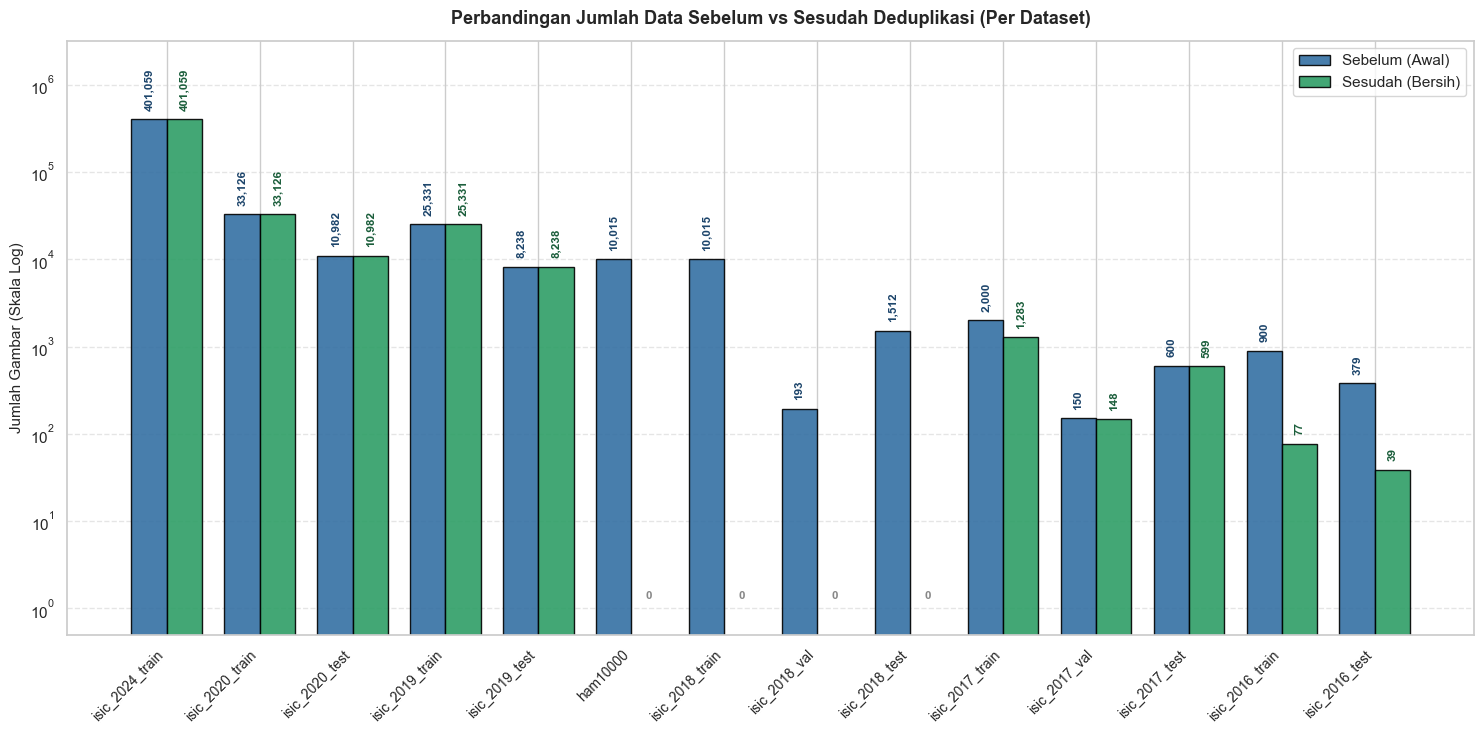

In [45]:
# Visualisasi Bar Chart Sebelum vs Sesudah Deduplikasi (Lengkap dengan Angka Jelas)
fig, ax = plt.subplots(figsize=(15, 7.5))
x = np.arange(len(df_before_after))
width = 0.38

b_vals = df_before_after['Before (Awal)'].tolist()
a_vals = df_before_after['After (Bersih)'].tolist()

rects1 = ax.bar(x - width/2, b_vals, width=width, label='Sebelum (Awal)', color='#3470a3', edgecolor='black', alpha=0.9)
rects2 = ax.bar(x + width/2, a_vals, width=width, label='Sesudah (Bersih)', color='#2e9e66', edgecolor='black', alpha=0.9)

# Tulis label angka di atas setiap batang secara jelas
for rect in rects1:
    h = rect.get_height()
    if h > 0:
        ax.text(
            rect.get_x() + rect.get_width() / 2.0, 
            h * 1.25, 
            f"{int(h):,}", 
            ha='center', 
            va='bottom', 
            fontsize=8.5, 
            rotation=90, 
            color='#1d456b', 
            fontweight='bold'
        )

for rect in rects2:
    h = rect.get_height()
    if h > 0:
        ax.text(
            rect.get_x() + rect.get_width() / 2.0, 
            h * 1.25, 
            f"{int(h):,}", 
            ha='center', 
            va='bottom', 
            fontsize=8.5, 
            rotation=90, 
            color='#1b5e3b', 
            fontweight='bold'
        )
    else:
        # Jika data bersih 0 (karena 100% duplikat tereliminasi)
        ax.text(
            rect.get_x() + rect.get_width() / 2.0, 
            1.2, 
            "0", 
            ha='center', 
            va='bottom', 
            fontsize=8.5, 
            color='#888888', 
            fontweight='bold'
        )

ax.set_xticks(x)
ax.set_xticklabels(df_before_after['Source Dataset'], rotation=45, ha='right', fontsize=10)
ax.set_ylabel('Jumlah Gambar (Skala Log)', fontsize=11)
ax.set_yscale('log')
ax.set_ylim(0.5, max(b_vals) * 8)
ax.set_title('Perbandingan Jumlah Data Sebelum vs Sesudah Deduplikasi (Per Dataset)', fontsize=13, fontweight='bold', pad=12)
ax.legend(fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Langkah 8 — Simpan Metadata Dataset Bersih
Menyimpan metadata 480.882 citra unik hasil deduplikasi ke file CSV `dataset_clean_final.csv`.

In [46]:
# Simpan hasil deduplikasi final ke CSV
output_clean_path = os.path.join(ROOT, 'dataset_clean_final.csv')
cols_to_save = ['image_id', 'source', 'filepath']
df_clean[cols_to_save].to_csv(output_clean_path, index=False)

print(f"Dataset bersih berhasil disimpan ke: {output_clean_path}")
print(f"Total baris data bersih: {len(df_clean):,} gambar.")
print("\nContoh 10 baris pertama dataset bersih:")
display(df_clean[cols_to_save].head(10))

Dataset bersih berhasil disimpan ke: c:\Users\ARII\Downloads\Data Understanding Isic & Ham10k\Dataset\dataset_clean_final.csv
Total baris data bersih: 480,882 gambar.

Contoh 10 baris pertama dataset bersih:


,image_id,source,filepath
15749,ISIC_0000000,isic_2019_train,c:\Users\ARII\Downloads\Data Understanding Isi...
15750,ISIC_0000001,isic_2019_train,c:\Users\ARII\Downloads\Data Understanding Isi...
15751,ISIC_0000002,isic_2019_train,c:\Users\ARII\Downloads\Data Understanding Isi...
15752,ISIC_0000003,isic_2019_train,c:\Users\ARII\Downloads\Data Understanding Isi...
15753,ISIC_0000004,isic_2019_train,c:\Users\ARII\Downloads\Data Understanding Isi...
15754,ISIC_0000006,isic_2019_train,c:\Users\ARII\Downloads\Data Understanding Isi...
15755,ISIC_0000007,isic_2019_train,c:\Users\ARII\Downloads\Data Understanding Isi...
15756,ISIC_0000008,isic_2019_train,c:\Users\ARII\Downloads\Data Understanding Isi...
15757,ISIC_0000009,isic_2019_train,c:\Users\ARII\Downloads\Data Understanding Isi...
15758,ISIC_0000010,isic_2019_train,c:\Users\ARII\Downloads\Data Understanding Isi...
